
### Predicting Boston House Prices

**Dataset:** housing.csv  
**Target Variable:** `MEDV` (median value of owner-occupied homes in $1000s)  
**Problem Type:** Multiple Linear Regression  

---

**Pipeline Overview:**
1. Import Libraries
2. Load the Dataset
3. Initial Data Inspection
4. Exploratory Data Analysis
5. Prepare Features and Target
6. Train / Test Split
7. Build the Linear Regression Model
8. Evaluate the Model
9. Residual Diagnostics — Testing the Four Assumptions

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

In [2]:
# the csv has no header row and uses whitespace as a separator, so we define the column names manually
cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('housing.csv', sep=r'\s+', header=None, names=cols)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 3. Initial Data Inspection

Before building the model we need to understand the dataset's structure — how many rows and columns it contains, what the data types are, and whether any missing values exist.

In [3]:
# show the number of rows and columns in the dataset
df.shape

(506, 14)

In [4]:
# show column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### DataFrame Information

The `info()` output gives us a structural overview of the dataset. It tells us the number of entries, the column names, the data type of each column, and whether any null values are present.

The dataset contains **506 rows and 14 columns**. All features are numerical, so no encoding is required. We can inspect the null count column to determine whether any missing value treatment is needed before modelling.

In [5]:
# show a statistical summary to understand the spread, minimum, maximum and potential outliers
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Descriptive Statistics

The `describe()` output gives a quick statistical summary for every numerical column. Key things to note are the mean and standard deviation of each feature, the minimum and maximum values, and whether the median (50th percentile) is far from the mean — a large gap between the two suggests skewness in that column.

In [6]:
# check for missing values across all columns
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## 4. Exploratory Data Analysis

The assignment specifies four predictor variables: **RM** (average number of rooms per dwelling), **LSTAT** (percentage of lower-status population), **PTRATIO** (pupil-teacher ratio by town), and **CRIM** (per capita crime rate). The target variable is **MEDV** (median house value in $1000s).

EDA is performed on these selected variables before modelling. The goal is to understand the distribution of the target variable and examine how each predictor relates to it.

### 4.1 Target Variable Distribution

For regression we always inspect the distribution of the target variable first. A heavily skewed target will produce skewed residuals, which violates the normality assumption of linear regression.

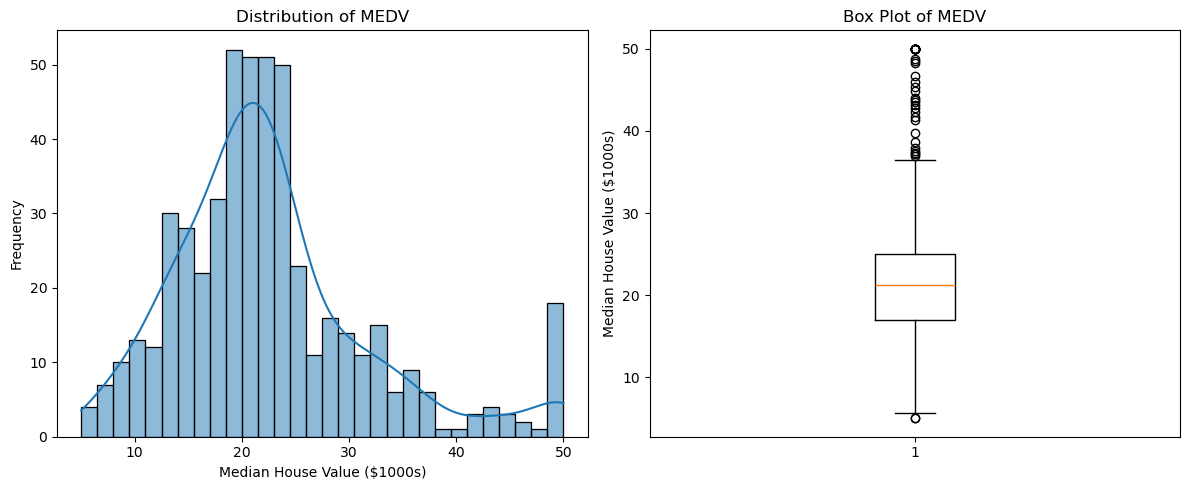

In [7]:
# plot the distribution and box plot of the target variable side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['MEDV'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Distribution of MEDV')
axes[0].set_xlabel('Median House Value ($1000s)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['MEDV'])
axes[1].set_title('Box Plot of MEDV')
axes[1].set_ylabel('Median House Value ($1000s)')

plt.tight_layout()
plt.show()

### 4.2 Scatter Plots — Predictors vs Target

Scatter plots show the relationship between each predictor and the target variable. A clear linear trend (upward or downward) indicates that the predictor is a useful candidate for a linear regression model. A red regression line is overlaid on each plot to make the direction and strength of the relationship easier to read.

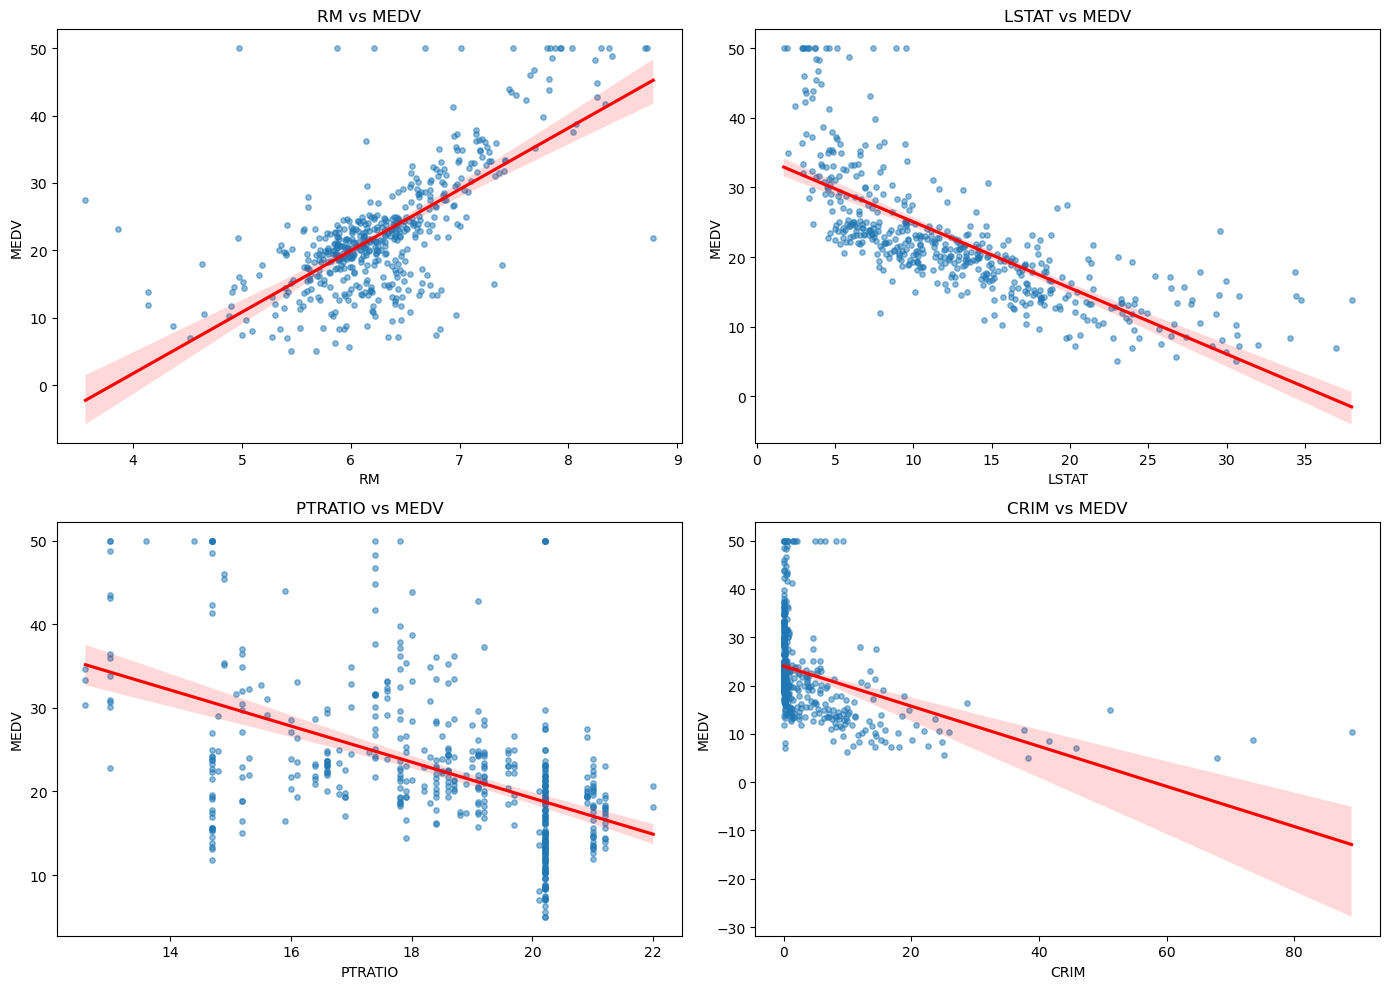

In [8]:
# scatter plots for each of the four selected predictors against MEDV
predictors = ['RM', 'LSTAT', 'PTRATIO', 'CRIM']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(predictors):
    axes[i].scatter(df[feature], df['MEDV'], alpha=0.5, s=15)
    sns.regplot(x=df[feature], y=df['MEDV'], ax=axes[i], scatter=False, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{feature} vs MEDV')

plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

The correlation heatmap shows the strength of linear relationships between the selected predictors and the target variable. Values close to 1 or -1 indicate a strong relationship. Values close to 0 indicate a weak relationship. We also use this to check for multicollinearity — if two predictors correlate strongly with each other (above 0.95 in absolute terms), one of them may need to be removed.

MEDV       1.000000
RM         0.695360
CRIM      -0.388305
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


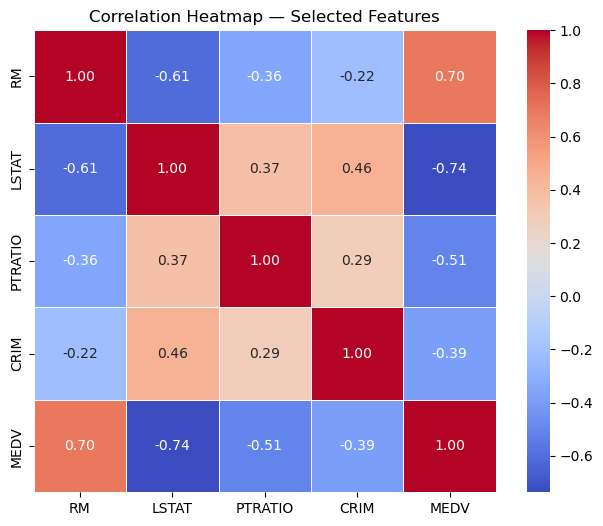

In [9]:
# select only the four predictors and the target for the correlation matrix
df_selected = df[['RM', 'LSTAT', 'PTRATIO', 'CRIM', 'MEDV']]

# print the correlation of each predictor with MEDV, sorted from strongest to weakest
correlations = df_selected.corr()['MEDV'].sort_values(ascending=False)
print(correlations)

# heatmap of all pairwise correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Selected Features')
plt.show()

## 5. Prepare Features and Target

We now isolate the four predictor variables and the target variable from the full dataset. The feature matrix `X` contains RM, LSTAT, PTRATIO and CRIM. The target vector `y` contains MEDV.

In [10]:
# define the predictor matrix and the target vector
X = df[['RM', 'LSTAT', 'PTRATIO', 'CRIM']]
y = df['MEDV']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)

Features shape: (506, 4)
Target shape:   (506,)


## 6. Train / Test Split

The data is split into a training set and a test set. The training set is used to fit the model and the test set is kept entirely separate to evaluate how well the model generalises to unseen data. We use an 80/20 split, which is the standard convention for datasets of this size.

`random_state=42` ensures the split is reproducible — running the notebook again will produce the same train and test sets.

In [11]:
# split the data into training and test sets using an 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape: (404, 4)
X_test shape:  (102, 4)
y_train shape: (404,)
y_test shape:  (102,)


## 7. Build the Linear Regression Model

Multiple Linear Regression finds the best-fitting hyperplane through the data by minimising the sum of squared differences between actual and predicted values. This method is called Ordinary Least Squares (OLS). The model learns a coefficient for each predictor, representing how much a one-unit change in that predictor shifts the predicted house price, assuming all other predictors are held constant.

In [12]:
# create and train the linear regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# display the intercept and the coefficient for each predictor
coef_df = pd.DataFrame({
    'Feature':     ['RM', 'LSTAT', 'PTRATIO', 'CRIM'],
    'Coefficient': model.coef_
})
print('Intercept:', round(model.intercept_, 4))
print()
print(coef_df.to_string(index=False))

Intercept: 12.3695

Feature  Coefficient
     RM     5.064279
  LSTAT    -0.520955
PTRATIO    -0.805403
   CRIM    -0.087283


In [14]:
# generate predictions on the test set
y_pred = model.predict(X_test)

In [15]:
# view the first 20 actual vs predicted values side by side
results = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred
})
results.head(20)

,Actual,Predicted
0,23.6,26.774743
1,32.4,30.574869
2,13.6,17.057559
3,22.8,24.736906
4,16.1,18.548908
5,20.0,22.862341
6,17.8,17.923311
7,14.0,13.950116
8,19.6,20.588539
9,16.8,19.943266


## 8. Evaluate the Model

Regression models are not evaluated with accuracy. Instead we use error-based metrics that measure how far the predictions are from the actual values.

| Metric | What It Measures | Good Result |
|--------|-----------------|-------------|
| **MAE** | Average absolute error in the same unit as the target | As small as possible |
| **MSE** | Average squared error — penalises larger errors more heavily | As small as possible |
| **RMSE** | Square root of MSE — back in the same unit as the target | As small as possible |
| **R²** | Proportion of variance in MEDV explained by the model | Closer to 1.0 |

In [16]:
# calculate all four evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('MAE: ', round(mae, 4))
print('MSE: ', round(mse, 4))
print('RMSE:', round(rmse, 4))
print('R²:  ', round(r2, 4))

MAE:  3.373
MSE:  27.9486
RMSE: 5.2866
R²:   0.6189


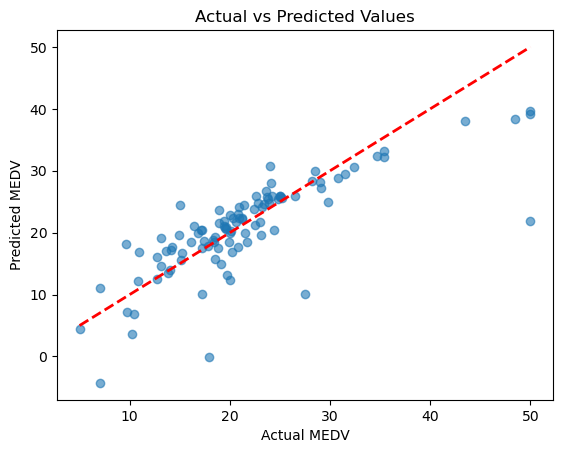

In [17]:
# scatter plot of actual vs predicted values — a perfect model would have all points on the diagonal
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Actual vs Predicted Values')
plt.show()

### Feature Significance — P-Value Analysis

Scikit-learn gives us predictions and error metrics but does not tell us whether each predictor is statistically significant. To determine significance we use **statsmodels OLS**, which produces a full regression summary including p-values for every coefficient.

A p-value answers the question: if this predictor had no real relationship with the target, how likely is it that we would still observe a coefficient this large by chance alone? A p-value below 0.05 is the standard threshold for statistical significance.

In [18]:
# statsmodels requires a constant column to be added manually for the intercept
X_train_sm = sm.add_constant(X_train.astype(float))

# fit the OLS model and print the full summary
ols_model = sm.OLS(y_train.astype(float), X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     224.1
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          1.33e-100
Time:                        15:16:03   Log-Likelihood:                -1237.2
No. Observations:                 404   AIC:                             2484.
Df Residuals:                     399   BIC:                             2504.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3695      4.347      2.845      0.0

In [19]:
# extract p-values into a clean readable table and flag each feature as significant or not
pval_df = pd.DataFrame({
    'Feature':     ols_model.model.exog_names[1:],
    'Coefficient': ols_model.params.values[1:],
    'P-Value':     ols_model.pvalues.values[1:]
})
pval_df['Significant (p < 0.05)'] = pval_df['P-Value'] < 0.05
pval_df = pval_df.sort_values('P-Value').reset_index(drop=True)
pval_df

,Feature,Coefficient,P-Value,Significant (p < 0.05)
0,RM,5.064279,8.190368e-24,True
1,LSTAT,-0.520955,1.678132e-22,True
2,PTRATIO,-0.805403,9.669993e-10,True
3,CRIM,-0.087283,7.954143e-03,True


## 9. Residual Diagnostics — Testing the Four Assumptions

Linear regression is only valid when four classical assumptions are satisfied. These assumptions are tested by analysing the **residuals** — the differences between the actual values and the model's predicted values.

The four assumptions are:

1. **Linearity** — the relationship between each predictor and the target is linear.
2. **Independence of errors** — the residuals are not correlated with any predictor.
3. **Homoscedasticity** — the variance of the residuals is constant across all predicted values.
4. **Normality of residuals** — the residuals follow an approximately normal distribution.

Each assumption is checked visually using the plots below.

In [20]:
# calculate the residuals for the test set
residuals = y_test.values - y_pred

print('Mean of residuals (should be close to 0):', round(float(residuals.mean()), 4))
print('Standard deviation of residuals:         ', round(float(residuals.std()), 4))

Mean of residuals (should be close to 0): 0.5329
Standard deviation of residuals:          5.2597


### 9.1 Residuals vs Predicted — Checks Assumptions 1 and 3

This plot checks two assumptions at once. For **Linearity** (Assumption 1) we look for the absence of any curved or systematic pattern — the residuals should be randomly scattered above and below the zero line with no visible trend. For **Homoscedasticity** (Assumption 3) we look for constant spread — the residuals should not fan out or narrow as the predicted value increases.

| What You See | What It Means |
|---|---|
| Random scatter around zero | Both assumptions are satisfied |
| Curved or U-shaped pattern | The relationship is non-linear — violates Assumption 1 |
| Funnel shape (spread increases) | Heteroscedasticity — violates Assumption 3 |

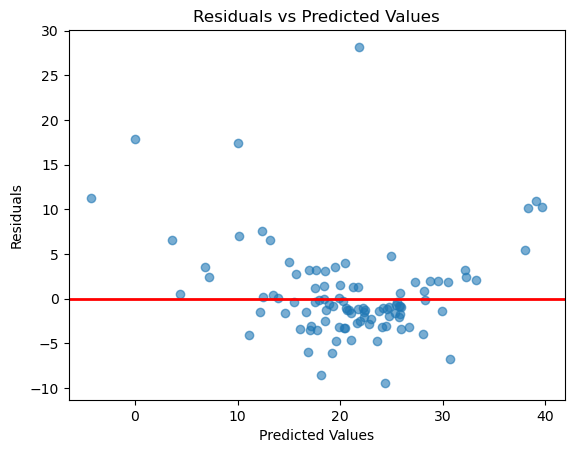

In [21]:
# residuals vs predicted — checks linearity and homoscedasticity
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### 9.2 Histogram of Residuals — Checks Assumption 4 (Normality)

The histogram checks whether the residuals follow a normal distribution. A bell-shaped curve centred close to zero confirms the normality assumption. A skewed histogram means the model is consistently over-predicting or under-predicting in one direction, which biases the results.

| What You See | What It Means |
|---|---|
| Bell-shaped curve centred at 0 | Normality assumption is satisfied |
| Right-skewed distribution | The model systematically under-predicts |
| Left-skewed distribution | The model systematically over-predicts |

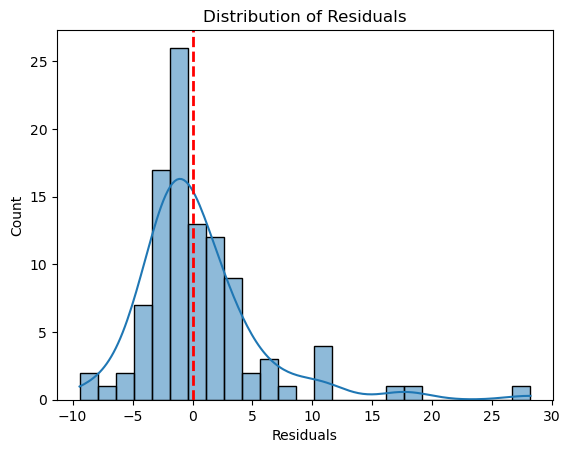

In [22]:
# histogram of residuals with a KDE curve — checks the normality assumption
sns.histplot(residuals, kde=True, bins=25)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

### 9.3 Q-Q Plot — Checks Assumption 4 (Normality)

The Q-Q (Quantile-Quantile) plot provides a more precise check of normality than the histogram. It compares the actual quantiles of the residuals against the theoretical quantiles of a perfect normal distribution. If the residuals are normally distributed, all points will fall close to the diagonal reference line.

| What You See | What It Means |
|---|---|
| Points follow the diagonal line closely | Normality is confirmed |
| Tails curve away from the line | Heavy tails — the model makes more extreme errors than expected |
| S-shaped curve | The residuals are skewed |

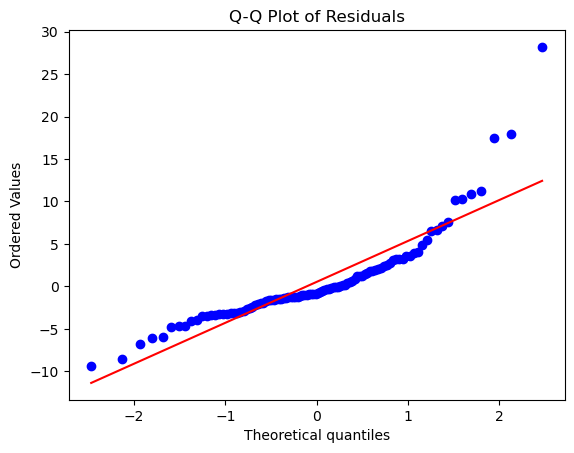

In [23]:
# Q-Q plot — compares residuals against a theoretical normal distribution
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

### 9.4 Residuals vs Each Predictor — Checks Assumption 2 (Independence)

This set of plots checks whether the residuals are independent of each predictor. If a predictor shows a curved or systematic pattern against the residuals, it means the model has not fully captured that predictor's relationship with the target — suggesting a linear term alone is insufficient.

The expected result is that the residuals are randomly scattered around zero for every predictor, with no visible trend or curve.

In [24]:
# build a results dataframe combining the test features with actual, predicted and residual values
df_result = X_test.copy().reset_index(drop=True)
df_result['Actual']    = y_test.values
df_result['Predicted'] = y_pred
df_result['Residuals'] = residuals

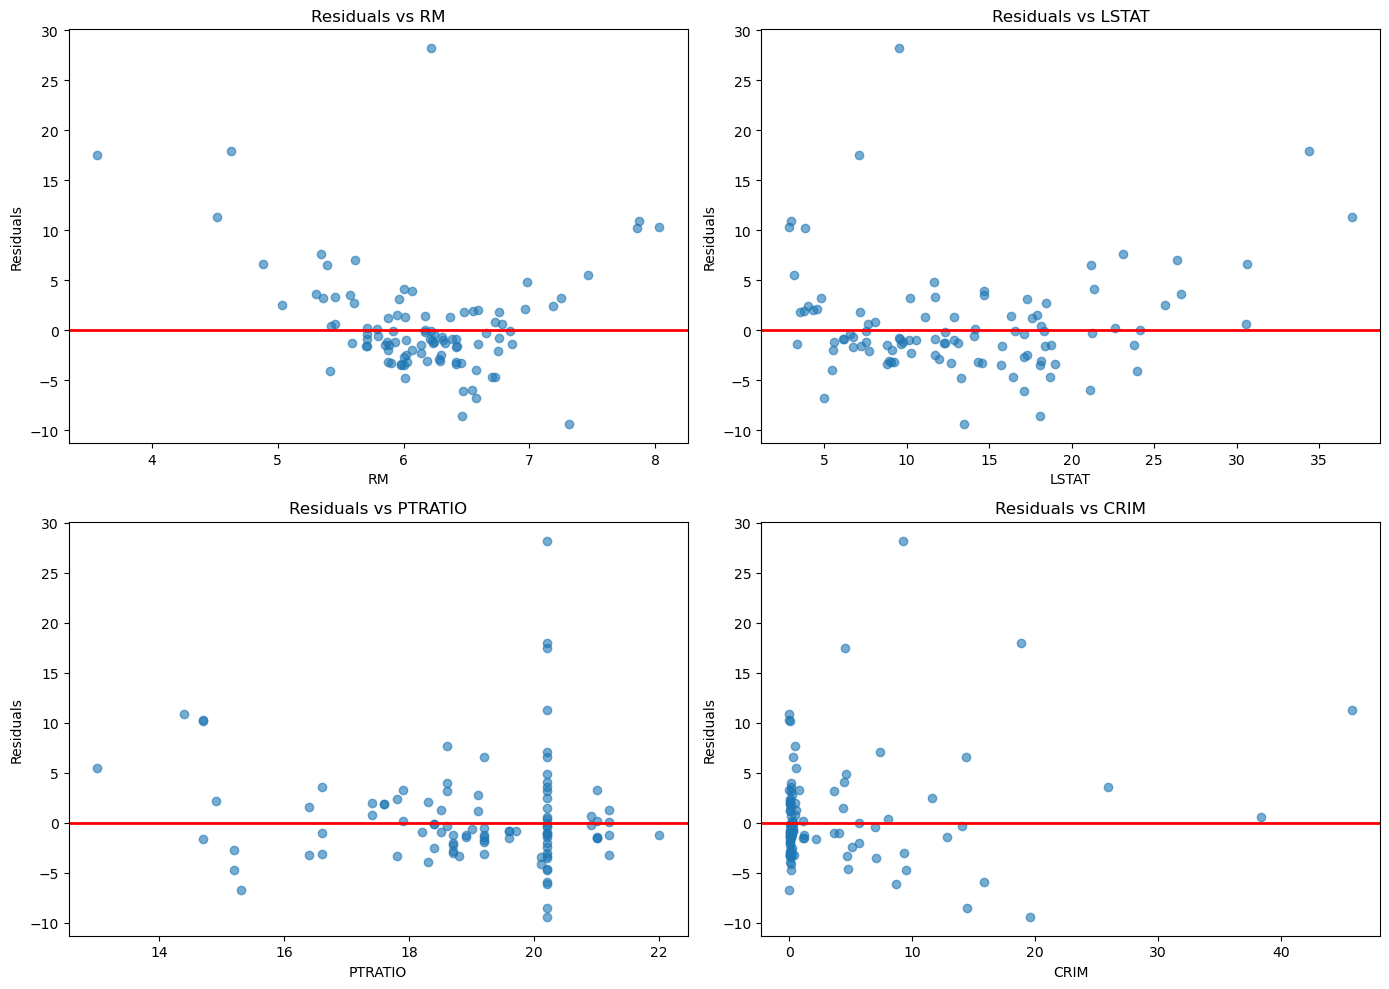

In [25]:
# plot residuals against each of the four predictors to check for feature-level patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(['RM', 'LSTAT', 'PTRATIO', 'CRIM']):
    axes[i].scatter(df_result[feature], df_result['Residuals'], alpha=0.6)
    axes[i].axhline(0, color='red', linewidth=2)
    axes[i].set_title(f'Residuals vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

### Residual Diagnostics Summary

The table below summarises which plot tests which assumption and what a satisfactory result looks like.

| Assumption | Plot Used | Satisfactory Result |
|---|---|---|
| Linearity | Residuals vs Predicted | No curve or pattern — random scatter around zero |
| Independence of errors | Residuals vs each predictor | No systematic pattern for any individual predictor |
| Homoscedasticity | Residuals vs Predicted | Constant spread — no funnel shape |
| Normality of residuals | Histogram and Q-Q Plot | Bell-shaped histogram and points on the diagonal in the Q-Q plot |

If any assumption is violated it does not necessarily mean the model is useless, but it does mean that the coefficient estimates and prediction intervals may not be reliable and further investigation is warranted.